# **Face Detection**
Detect face mask with CNN model.

## Import Important Libraries

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory

BATCH_SIZE=50

# **Loading Data**
## Import Train Data

In [6]:
train_df = image_dataset_from_directory('../input/face-mask-12k-images-dataset/Face Mask Dataset/Train/',
                                       labels='inferred',
                                       label_mode='binary',
                                       interpolation='nearest',
                                       image_size=[128,128],
                                       batch_size=BATCH_SIZE,
                                       shuffle=True,
                                       )

Found 10000 files belonging to 2 classes.


## Import Validation Data

In [7]:
valid_df = image_dataset_from_directory('../input/face-mask-12k-images-dataset/Face Mask Dataset/Validation/',
                                       labels='inferred',
                                       label_mode='binary',
                                       interpolation='nearest',
                                       image_size=[128,128],
                                       batch_size=BATCH_SIZE,
                                       shuffle=True,
                                       )

Found 800 files belonging to 2 classes.


## Import Test Data

In [8]:
test_df = image_dataset_from_directory('../input/face-mask-12k-images-dataset/Face Mask Dataset/Test/',
                                       labels='inferred',
                                       label_mode='binary',
                                       interpolation='nearest',
                                       image_size=[128,128],
                                       batch_size=BATCH_SIZE,
                                       shuffle=True,
                                       )

Found 992 files belonging to 2 classes.


In [9]:
# Storing the Class names in a List
class_name = train_df.class_names

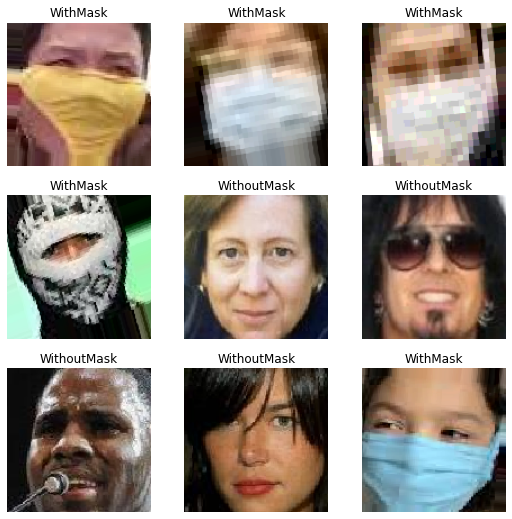

In [10]:
# Lets See Some Train Data Images

import matplotlib.pyplot as plt

plt.figure(figsize=(9,9))
for img, label in train_df.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(img[i].numpy().astype('uint8'))
        plt.title(class_name[int(label[i])])
        plt.axis('off')

In [11]:
# Autotune the all the dataset

AUTOTUNE = tf.data.AUTOTUNE

train_df = train_df.cache().prefetch(buffer_size=AUTOTUNE)
valid_df = valid_df.cache().prefetch(buffer_size=AUTOTUNE)
test_df = test_df.cache().prefetch(buffer_size=AUTOTUNE)

# **Model Architecture**

In [12]:
model = Sequential([
    # Input layer
    keras.Input(shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.ReLU(),
    
    # First Layer
    layers.Conv2D(filters=1024, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(),
    
    # Second Layer
    layers.Conv2D(filters=512, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(),
    
    # Third Layer
    layers.Conv2D(filters=256, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(),
    
    # Forth Layer
    layers.Conv2D(filters=128, kernel_size=3, padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPool2D(),
    layers.Dropout(0.2),
    
    # Classifier Head
    layers.GlobalAveragePooling2D(),
    layers.Dense(units=10,activation='relu'),
    layers.Dense(units=1,activation='sigmoid')
    
])

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization (BatchNo (None, 128, 128, 3)       12        
_________________________________________________________________
re_lu (ReLU)                 (None, 128, 128, 3)       0         
_________________________________________________________________
conv2d (Conv2D)              (None, 128, 128, 1024)    28672     
_________________________________________________________________
batch_normalization_1 (Batch (None, 128, 128, 1024)    4096      
_________________________________________________________________
re_lu_1 (ReLU)               (None, 128, 128, 1024)    0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 64, 64, 1024)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 64, 512)       4

In [14]:
model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['binary_accuracy'],
)

# **Model Training**

In [15]:
history = model.fit(train_df,
                   validation_data=valid_df,
                   epochs=2,
                   workers=4,
                   use_multiprocessing=True,
)

Epoch 1/2
200/200 [==============================] - 97s 485ms/step - loss: 0.2408 - binary_accuracy: 0.9063 - val_loss: 0.8118 - val_binary_accuracy: 0.6812


# **Model Evaluation**

In [16]:
model.evaluate(test_df)

20/20 [==============================] - 7s 242ms/step - loss: 0.7532 - binary_accuracy: 0.6976


[0.7531818151473999, 0.6975806355476379]

<AxesSubplot:>

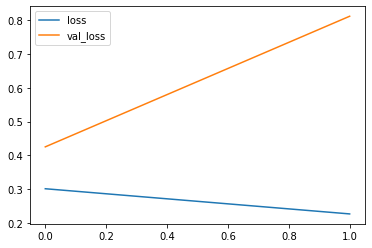

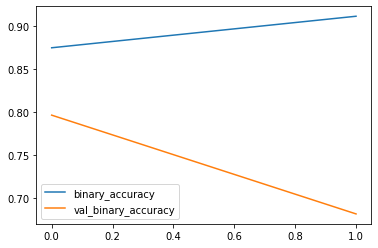

In [17]:
import pandas as pd
hist_df = pd.DataFrame(history.history)
hist_df.loc[:,['loss','val_loss']].plot()
hist_df.loc[:,['binary_accuracy','val_binary_accuracy']].plot()

In [18]:
# Save the Model
model.save('face_mask_detection.h5')

In [19]:
# function which return predictions

def get_class(img):
    img_arr = keras.preprocessing.image.img_to_array(img)
    img_arr = tf.expand_dims(img_arr, 0)
    pred = model.predict(img_arr)
    pred = (pred>0.5).astype(np.int)
    return class_name[pred[0][0]]

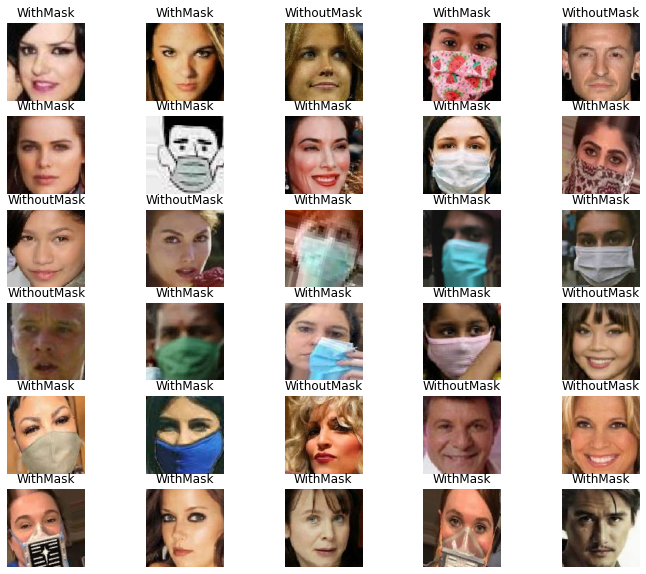

In [22]:
# Lets See the Predicted Results

plt.figure(figsize=(12,10))
for img , _ in test_df.take(5):
    for i in range(30):
        ax = plt.subplot(6,5,i+1)
        plt.imshow(img[i])
        plt.title(get_class(img[i]))
        plt.axis('off')